In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from PIL import Image
from sklearn.model_selection import train_test_split
import os
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


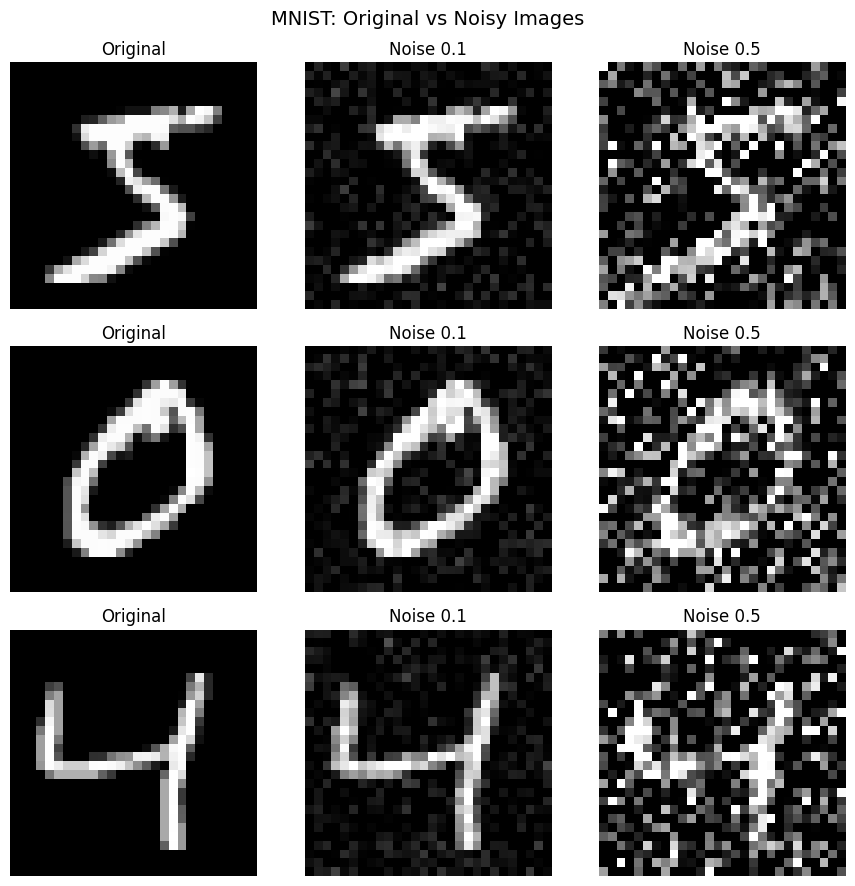

In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

noise_factor_low  = 0.1
noise_factor_high = 0.5

x_train_noisy_low  = x_train + noise_factor_low  * np.random.normal(0.0, 1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(0.0, 1.0, size=x_train.shape)
x_test_noisy_low   = x_test  + noise_factor_low  * np.random.normal(0.0, 1.0, size=x_test.shape)
x_test_noisy_high  = x_test  + noise_factor_high * np.random.normal(0.0, 1.0, size=x_test.shape)

x_train_noisy_low  = np.clip(x_train_noisy_low,  0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low   = np.clip(x_test_noisy_low,   0., 1.)
x_test_noisy_high  = np.clip(x_test_noisy_high,  0., 1.)

n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.suptitle("MNIST: Original vs Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded


def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded


def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder


autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1540 - val_loss: 0.1135
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1100 - val_loss: 0.1055
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1044 - val_loss: 0.1021
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1019 - val_loss: 0.1001
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1003 - val_loss: 0.0989
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0991 - val_loss: 0.0981
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0982 - val_loss: 0.0973
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0975 - val_loss: 0.0968
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0969 - val_loss: 0.0961
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0963 - val_loss: 0.0961


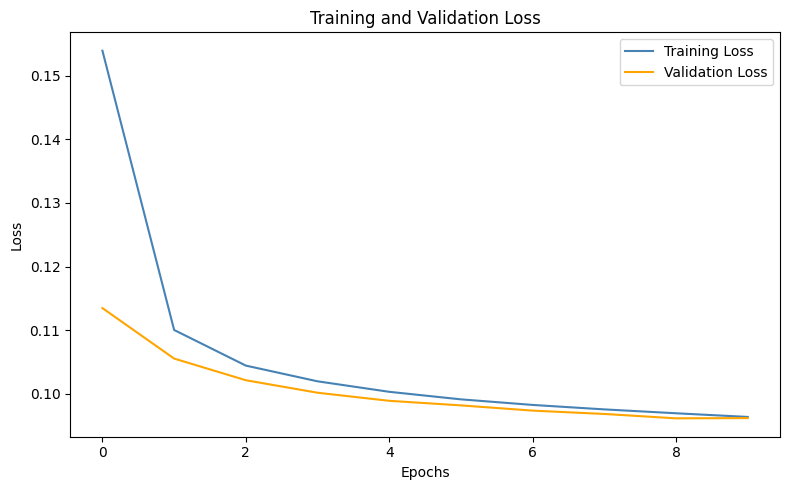

In [5]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


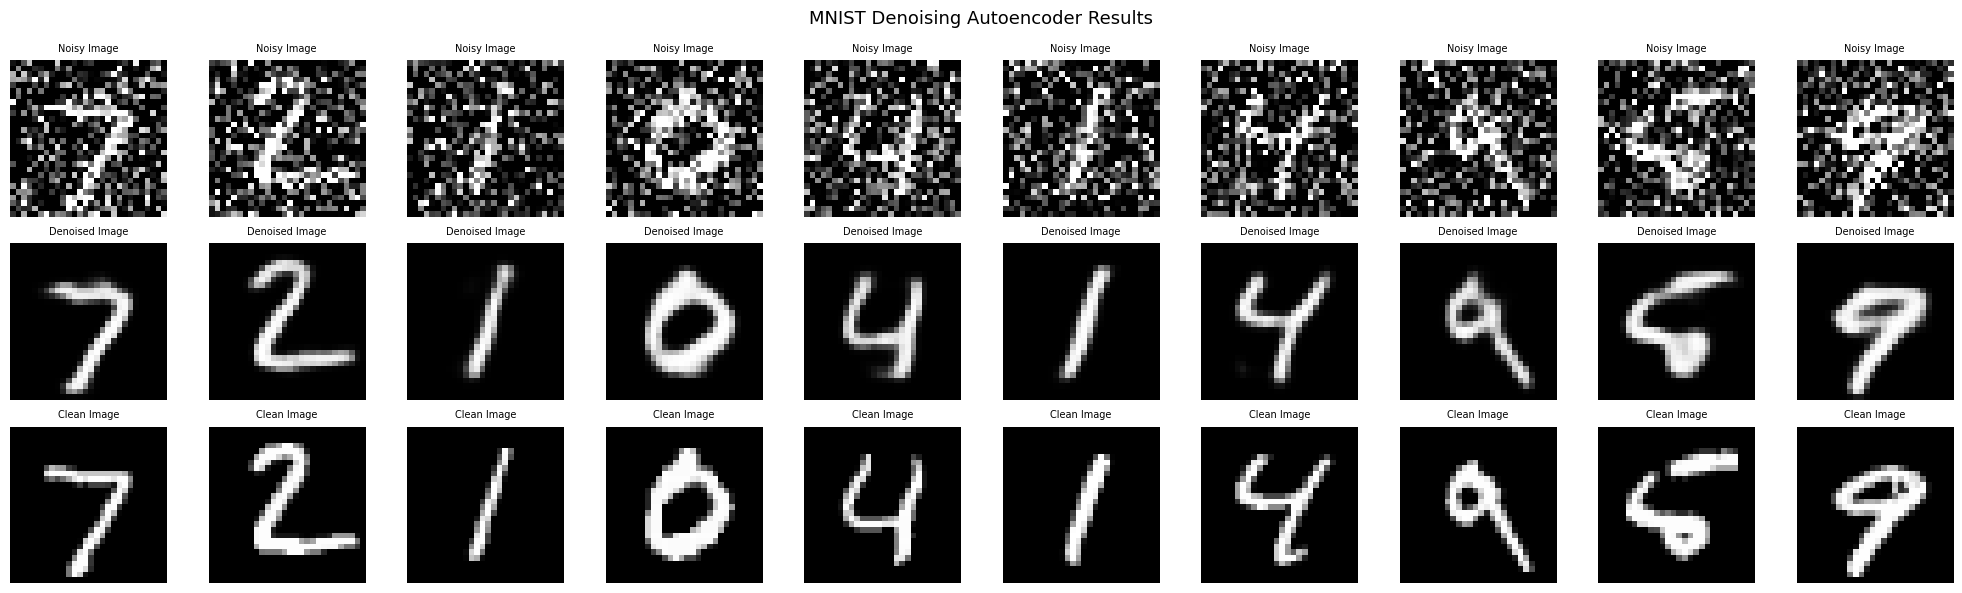

In [6]:
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image", fontsize=7)
        plt.axis('off')

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image", fontsize=7)
        plt.axis('off')

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image", fontsize=7)
        plt.axis('off')

    plt.suptitle("MNIST Denoising Autoencoder Results", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

In [7]:
zip_path     = "/content/drive/MyDrive/Bipin/AIML/Copy of devnagari digit.zip"
extract_path = "/content/DevnagariDataset"

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete.")

# Inspect what folders were extracted so we can find images
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

Extracting dataset...
Extraction complete.
DevnagariDataset/
  DevanagariHandwrittenDigitDataset/
    Train/
      digit_8/
      digit_7/
      digit_1/
      digit_2/
      digit_0/
      digit_5/
      digit_6/
      digit_4/
      digit_9/
      digit_3/
    Test/
      digit_8/
      digit_7/
      digit_1/
      digit_2/
      digit_0/
      digit_5/
      digit_6/
      digit_4/
      digit_9/
      digit_3/


In [8]:
IMG_SIZE = 32
images   = []

# Auto-detect the root folder that contains subfolders of digit classes
dataset_root = None
for root, dirs, files in os.walk(extract_path):
    # Look for a folder that has multiple subfolders (digit classes)
    image_exts = ('.png', '.jpg', '.jpeg', '.bmp')
    subfolders_with_images = [
        d for d in dirs
        if any(
            f.lower().endswith(image_exts)
            for f in os.listdir(os.path.join(root, d))
            if os.path.isfile(os.path.join(root, d, f))
        )
    ]
    if len(subfolders_with_images) >= 2:
        dataset_root = root
        print(f"Dataset root found: {root}")
        print(f"Classes found: {sorted(subfolders_with_images)}")
        break

if dataset_root is None:
    raise FileNotFoundError(
        "Could not find digit class subfolders. "
        "Please check the printed folder structure above and set dataset_root manually."
    )

# Load all images from each class subfolder
for class_name in sorted(os.listdir(dataset_root)):
    class_path = os.path.join(dataset_root, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            fpath = os.path.join(class_path, fname)
            try:
                img = Image.open(fpath).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))
            except Exception as e:
                print(f"Skipping {fpath}: {e}")

images = np.array(images, dtype='float32') / 255.0
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(f"Total images loaded : {images.shape[0]}")
print(f"Image shape         : {images.shape[1:]}")
print(f"Pixel range         : [{images.min():.2f}, {images.max():.2f}]")

Dataset root found: /content/DevnagariDataset/DevanagariHandwrittenDigitDataset/Train
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Total images loaded : 17000
Image shape         : (32, 32, 1)
Pixel range         : [0.00, 1.00]


Training samples    : 14450
Validation samples  : 2550


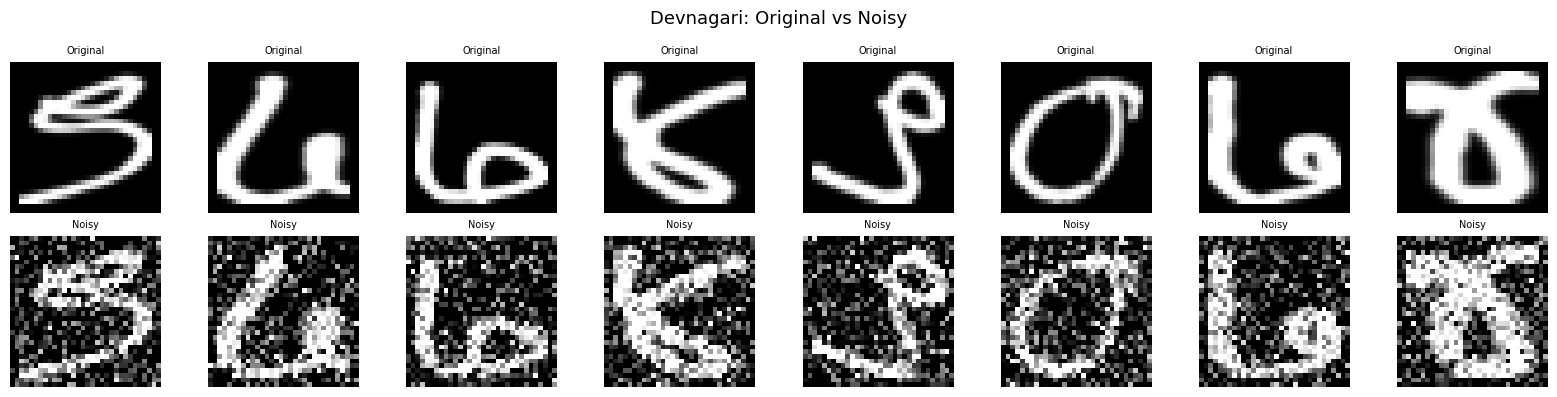

In [9]:
x_train_dev, x_val_dev = train_test_split(images, test_size=0.15, random_state=42)

noise_factor = 0.4

def add_gaussian_noise(data, factor=0.4):
    noisy = data + factor * np.random.normal(0.0, 1.0, size=data.shape)
    return np.clip(noisy, 0., 1.)

x_train_dev_noisy = add_gaussian_noise(x_train_dev, noise_factor)
x_val_dev_noisy   = add_gaussian_noise(x_val_dev,   noise_factor)

print(f"Training samples    : {x_train_dev.shape[0]}")
print(f"Validation samples  : {x_val_dev.shape[0]}")

# Visualize sample images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_train_dev[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[0, i].set_title("Original", fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train_dev_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[1, i].set_title("Noisy", fontsize=7)
    axes[1, i].axis('off')

plt.suptitle("Devnagari: Original vs Noisy", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
def build_devnagari_encoder(input_shape=(32, 32, 1)):
    """
    4-layer deep encoder:
      Layer 1: Conv2D(32)  + MaxPool  -> 16x16x32
      Layer 2: Conv2D(64)  + MaxPool  -> 8x8x64
      Layer 3: Conv2D(128)            -> 8x8x128
      Layer 4: Conv2D(128) bottleneck -> 8x8x128
    """
    input_img = Input(shape=input_shape, name="dev_input")

    x = Conv2D(32,  (3, 3), activation='relu', padding='same', name="enc_conv1")(input_img)
    x = MaxPooling2D((2, 2), padding='same', name="enc_pool1")(x)

    x = Conv2D(64,  (3, 3), activation='relu', padding='same', name="enc_conv2")(x)
    x = MaxPooling2D((2, 2), padding='same', name="enc_pool2")(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same', name="enc_conv3")(x)

    encoded = Conv2D(128, (3, 3), activation='relu', padding='same', name="encoded_dev")(x)

    return input_img, encoded


def build_devnagari_decoder(encoded_input):
    """
    4-layer deep decoder (mirrors encoder):
      Layer 1: Conv2D(128)
      Layer 2: Conv2D(64)  + UpSample -> 16x16x64
      Layer 3: Conv2D(32)  + UpSample -> 32x32x32
      Layer 4: Conv2D(1, sigmoid)     -> 32x32x1
    """
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name="dec_conv1")(encoded_input)

    x = Conv2D(64,  (3, 3), activation='relu', padding='same', name="dec_conv2")(x)
    x = UpSampling2D((2, 2), name="dec_up1")(x)

    x = Conv2D(32,  (3, 3), activation='relu', padding='same', name="dec_conv3")(x)
    x = UpSampling2D((2, 2), name="dec_up2")(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded_dev")(x)

    return decoded


def build_devnagari_autoencoder():
    input_img, encoded_out = build_devnagari_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
    decoded_out = build_devnagari_decoder(encoded_out)
    model = Model(inputs=input_img, outputs=decoded_out, name="devnagari_autoencoder")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model


dev_autoencoder = build_devnagari_autoencoder()
dev_autoencoder.summary()

Model: "devnagari_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dev_input (InputLayer)          │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_dev (Conv2D)            │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded_dev (Conv2D)            │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,385 (1.83 MB)

 Trainable params: 480,385 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.2481 - val_loss: 0.1505 - learning_rate: 0.0010
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1439 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1377 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1353 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1332 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1318 - val_loss: 0.1325 - learning_rate: 0.0010
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1309 - val_loss: 0.1324 - learning_rate: 0.0010
Epoch 8/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1302 - val_loss: 0.1315 - learning_rate: 0.0010
Epoch 9/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1293 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 10

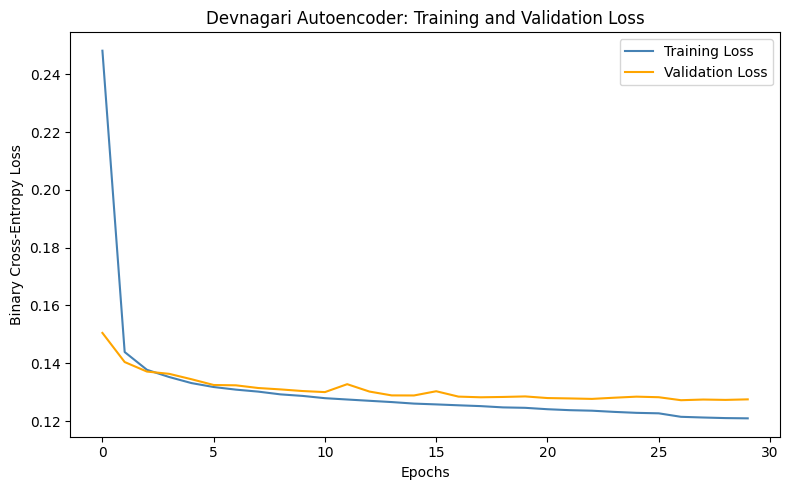

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, verbose=1
)

dev_history = dev_autoencoder.fit(
    x_train_dev_noisy, x_train_dev,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_val_dev_noisy, x_val_dev),
    callbacks=[early_stop, reduce_lr]
)

plt.figure(figsize=(8, 5))
plt.plot(dev_history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(dev_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Devnagari Autoencoder: Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


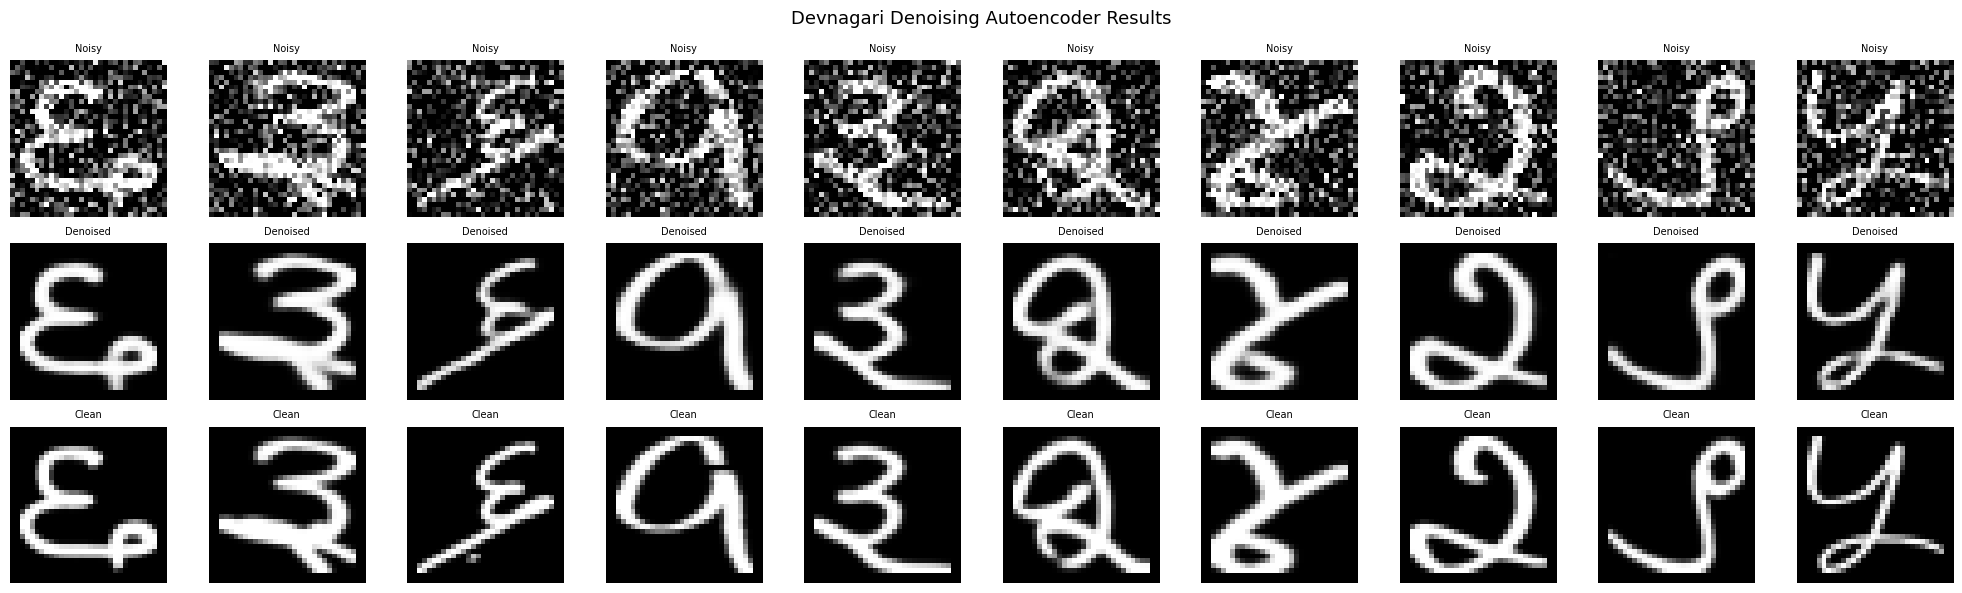

In [12]:
dev_denoised = dev_autoencoder.predict(x_val_dev_noisy)

def plot_devnagari_results(noisy, denoised, clean, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Noisy", fontsize=7)
        plt.axis('off')

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Denoised", fontsize=7)
        plt.axis('off')

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Clean", fontsize=7)
        plt.axis('off')

    plt.suptitle("Devnagari Denoising Autoencoder Results", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_devnagari_results(x_val_dev_noisy, dev_denoised, x_val_dev, n=10)

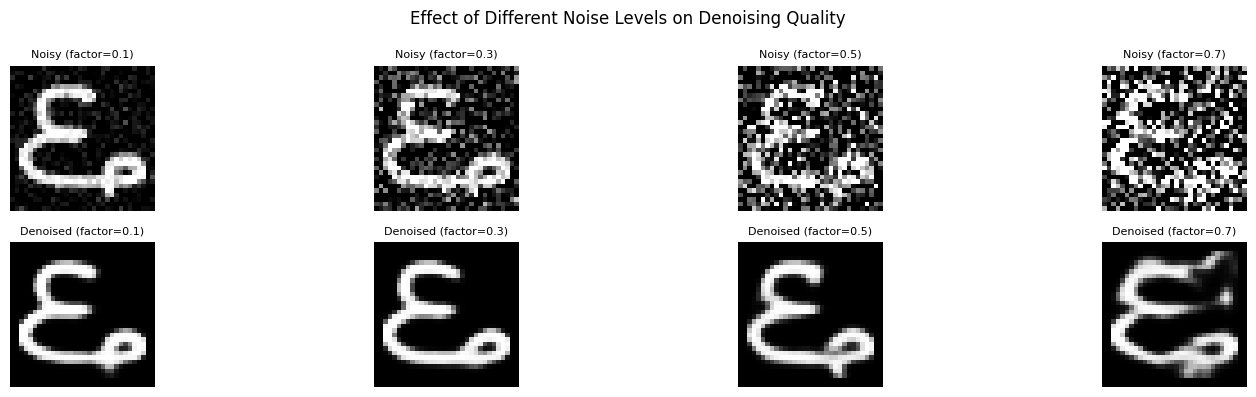

Noise Factor    MSE       
-------------------------
0.1             0.003655
0.3             0.005037
0.5             0.010286
0.7             0.028507


In [13]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
sample_img   = x_val_dev[:1]

plt.figure(figsize=(16, 4))
for idx, nf in enumerate(noise_levels):
    noisy  = np.clip(sample_img + nf * np.random.normal(0, 1, sample_img.shape), 0., 1.)
    result = dev_autoencoder.predict(noisy, verbose=0)

    plt.subplot(2, len(noise_levels), idx + 1)
    plt.imshow(noisy[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Noisy (factor={nf})", fontsize=8)
    plt.axis('off')

    plt.subplot(2, len(noise_levels), idx + 1 + len(noise_levels))
    plt.imshow(result[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Denoised (factor={nf})", fontsize=8)
    plt.axis('off')

plt.suptitle("Effect of Different Noise Levels on Denoising Quality", fontsize=12)
plt.tight_layout()
plt.show()

# MSE per noise level
print(f"{'Noise Factor':<15} {'MSE':<10}")
print("-" * 25)
for nf in noise_levels:
    noisy  = np.clip(x_val_dev + nf * np.random.normal(0, 1, x_val_dev.shape), 0., 1.)
    result = dev_autoencoder.predict(noisy, verbose=0)
    mse    = np.mean((x_val_dev - result) ** 2)
    print(f"{nf:<15} {mse:.6f}")